# ✅ Loan Approval Prediction

Binary classification task: predict whether an HDFC loan application will be **Approved** or **Rejected**.

**Notebook outline:**
1. Imports & setup
2. Data loading & feature engineering
3. Data quality check
4. Feature & target selection
5. Preprocessing pipeline
6. Train/test split
7. Logistic Regression baseline
8. Decision Tree
9. Random Forest with GridSearch
10. Model evaluation & comparison
11. Save best model

## 1. Imports & Setup

Load all required libraries and configure warnings.

In [1]:
import sys
import os
import warnings
import joblib

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(".."))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from src.preprocessing import *
from src.feature_engineering import *
from src.train import *
from src.evaluate import *
from src.utils import *

## 2. Data Loading & Feature Engineering

Load the raw dataset and engineer domain-specific features (total income, EMI ratio, loan-income ratio, etc.) using `src/feature_engineering.py`.

In [2]:
df = load_dataset("../dataset/hdfc_loan_dataset_full_enriched.csv")
df = basic_cleaning(df)

In [3]:
df = create_features(df)

## 3. Data Quality Check

Verify there are no significant missing values in the selected features.

In [4]:
missing_value_summary(df)

,Missing Values,Percentage
Business_Type,799,79.9
Co-signer_Relationship,234,23.4


## 4. Feature & Target Selection

Choose the predictor columns and encode the binary target `Loan_Status` (Approved/Rejected) with a LabelEncoder.

In [5]:
features = [
    "Applicant_Income",
    "Coapplicant_Income",
    "Loan_Amount",
    "Credit_History",
    "CIBIL_Score",
    "Employment_Status",
    "Existing_EMIs",
    "Debt_to_Income_Ratio",
    "Education",
    "Property_Area",

    "Total_Income",
    "Loan_Income_Ratio",
    "EMI_Income_Ratio"

]

target = "Loan_Status"
X, y = select_features(
    df,
    features,
    target
)

In [6]:
le = LabelEncoder()
y = le.fit_transform(y)

## 5. Preprocessing Pipeline

Build a `ColumnTransformer` that imputes and scales numerical features and one-hot encodes categorical features.

In [7]:
num_features, cat_features = get_feature_types(X)

In [8]:
preprocessor = create_preprocessor(
    num_features,
    cat_features
)

## 6. Train / Test Split

Split data 80/20 with stratification on the target class.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (800, 13)
Testing Shape : (200, 13)


## 7. Logistic Regression (Baseline)

Train a simple logistic regression model as a performance baseline.

In [10]:
lr_pipeline = build_pipeline(
    preprocessor,
    LogisticRegression(random_state=42),
)

In [11]:
lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
lr_pred = predict(
    lr_pipeline,
    X_test
)

In [13]:
lr_results = evaluate_classification(
    y_test,
    lr_pred,
)
lr_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Model,0.81,0.806783,0.81,0.806969


## 8. Decision Tree Classifier

Train a decision tree and compare against the logistic regression baseline.

In [14]:
dt_pipeline = build_pipeline(
    preprocessor,
    DecisionTreeClassifier(random_state=42)
)

In [15]:
dt_pipeline.fit(X_train, y_train)
dt_pred = predict(
    dt_pipeline,
    X_test
)

In [16]:
dt_results = evaluate_classification(
    y_test,
    dt_pred,
)
dt_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Model,0.82,0.821358,0.82,0.820593


## 9. Random Forest with GridSearchCV

Tune a Random Forest over a parameter grid (`n_estimators`, `max_depth`) using 5-fold cross-validation.

In [17]:
rf_pipeline = build_pipeline(
    preprocessor,
    RandomForestClassifier(random_state=42)
)

rf_pipeline.fit(X_train,y_train)
rf_pred = predict(
    rf_pipeline,
    X_test
)

rf_result = evaluate_classification(
    y_test,
    rf_pred
)
rf_result

,Model,Accuracy,Precision,Recall,F1 Score
0,Model,0.845,0.843231,0.845,0.843538


In [18]:
rf_params = {
    "classifier__n_estimators":[100,200],
    "classifier__max_depth":[5,10,15],
    "classifier__min_samples_split":[2,5],
    "classifier__min_samples_leaf":[1,2]
}

In [19]:
grid_rf = perform_grid_search(
    rf_pipeline,
    rf_params,
    X_train,
    y_train
)

In [20]:
best_rf = grid_rf.best_estimator_

In [21]:
grid_pred = predict(
    best_rf,
    X_test
)

## 10. Model Evaluation & Comparison

Compare all three models on the test set. Generate confusion matrix, ROC curve, and feature importance chart for the best model.

In [22]:
results = evaluate_classification(
    y_test,
    grid_pred
)
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Model,0.83,0.827713,0.83,0.828039


In [23]:
print_classification_report(
    y_test,
    grid_pred
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       131
           1       0.78      0.71      0.74        69

    accuracy                           0.83       200
   macro avg       0.82      0.80      0.81       200
weighted avg       0.83      0.83      0.83       200



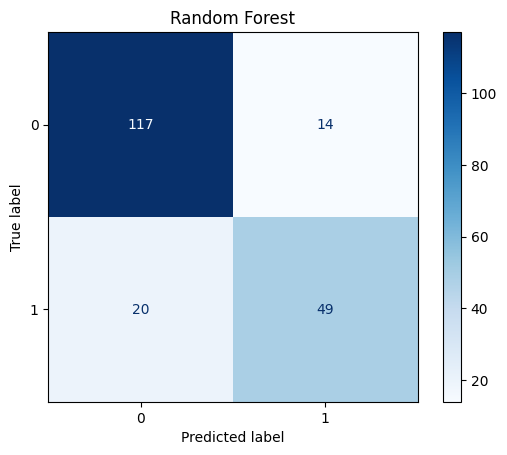

In [24]:
plot_confusion_matrix(
    y_test,
    grid_pred,
    "Random Forest"
)

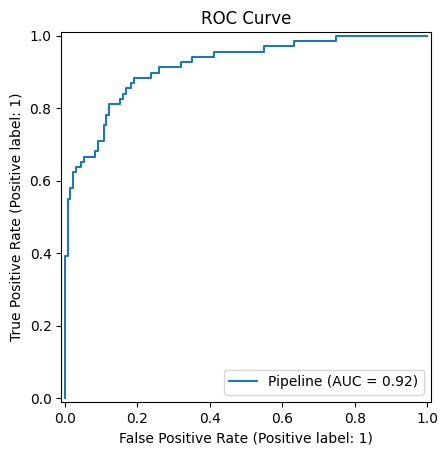

In [25]:
plot_roc_curve(
    best_rf,
    X_test,
    y_test
)

In [26]:
feature_names = best_rf.named_steps[
    "preprocessor"
].get_feature_names_out()

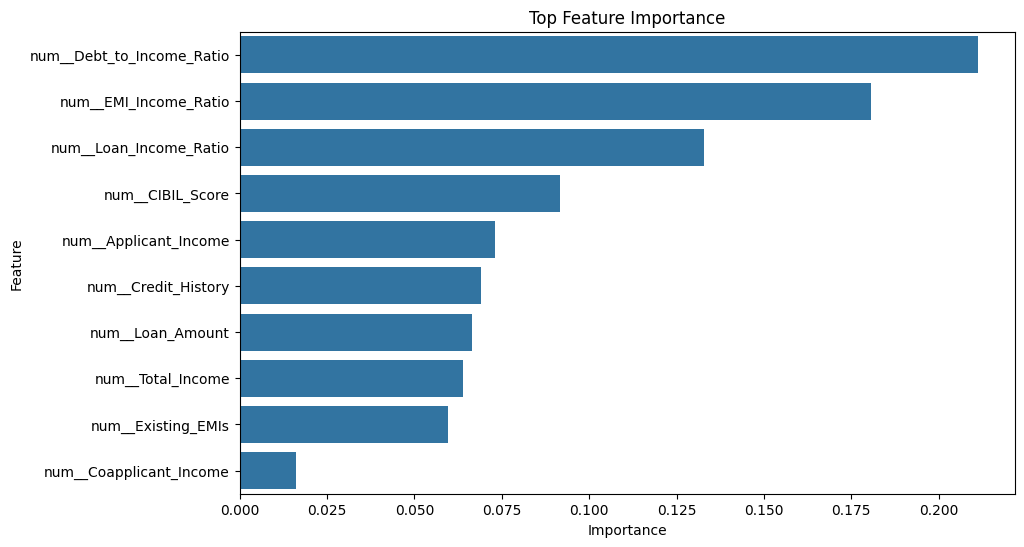

,Feature,Importance
6,num__Debt_to_Income_Ratio,0.211165
9,num__EMI_Income_Ratio,0.180738
8,num__Loan_Income_Ratio,0.132987
4,num__CIBIL_Score,0.091721
0,num__Applicant_Income,0.073086
3,num__Credit_History,0.069009
2,num__Loan_Amount,0.066331
7,num__Total_Income,0.063947
5,num__Existing_EMIs,0.059490
1,num__Coapplicant_Income,0.016118


In [27]:
plot_feature_importance(
    best_rf,
    feature_names
)

## 11. Save Best Model

Persist the best Random Forest pipeline to disk with `joblib` for later inference.

In [28]:
save_model(best_rf, "../models/loan_approval_model.pkl")

Model saved → ../models/loan_approval_model.pkl
